In [1]:
# 06 — Training dataset image geometry: pixel spacing, slice spacing, matrix size
# Reads only work/manifest/manifest.csv (values already extracted from the DICOM headers); no DICOM is opened.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path("F:/Kaggle/data")
TRAIN_SERIES_CSV = DATA_ROOT / "train_series.csv"
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MANIFEST_CSV = REPO_ROOT / "work/manifest/manifest.csv"

BAR_COLOR = "#2a78d6"
INK_MUTED = "#52514e"
GRID_COLOR = "#e6e5e0"
PLANE_ORDER = ["Sagittal", "Coronal", "Axial"]


def style_axes(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8, zorder=0)
    for side in ("top", "right", "left" if grid_axis == "y" else "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis=grid_axis, length=0)


def fmt_int(v):
    return f"{v:,}"


def histogram(values, bin_width, xlabel, title, unit="mm"):
    values = values.dropna()
    bins = np.arange(np.floor(values.min() / bin_width) * bin_width, values.max() + bin_width, bin_width)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(values, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.5, zorder=2)
    median = values.median()
    ax.axvline(median, color=INK_MUTED, linewidth=1, linestyle="--", zorder=3)
    ax.text(median, ax.get_ylim()[1], f" median {median:.2f} {unit}", va="top", fontsize=9, color=INK_MUTED)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of series")
    ax.set_title(f"{title} (n = {fmt_int(len(values))} series)", loc="left", fontsize=12)
    style_axes(ax)
    plt.tight_layout()
    plt.show()


def per_plane_summary(column):
    return (geo.groupby("Anatomical_Plane")[column].describe(percentiles=[0.05, 0.5, 0.95])
            .reindex(PLANE_ORDER).round(3))


if not MANIFEST_CSV.is_file():
    raise FileNotFoundError(f"Not found: {MANIFEST_CSV}. Build the manifest first.")
series = pd.read_csv(TRAIN_SERIES_CSV, dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str})
manifest = pd.read_csv(
    MANIFEST_CSV,
    dtype={"SeriesInstanceUID": str},
    usecols=["SeriesInstanceUID", "rows", "cols", "row_spacing_mm", "col_spacing_mm", "slice_spacing_mm", "n_slices"],
).drop_duplicates("SeriesInstanceUID")  # a series may split into several volumes; keep the first one
geo = series.merge(manifest, on="SeriesInstanceUID", how="inner")
print(f"{fmt_int(len(geo))} / {fmt_int(len(series))} training series have geometry in the manifest.")


24,371 / 24,371 training series have geometry in the manifest.


Non-square pixels: 0 series


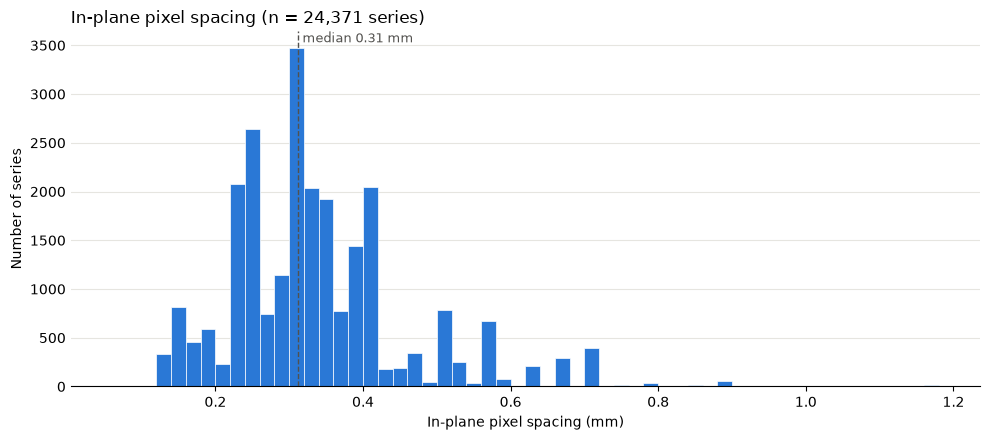

,count,mean,std,min,5%,50%,95%,max
Anatomical_Plane,,,,,,,,
Sagittal,9864.0,0.344,0.129,0.125,0.167,0.332,0.625,0.938
Coronal,8609.0,0.338,0.117,0.137,0.167,0.312,0.562,0.938
Axial,5898.0,0.332,0.125,0.073,0.156,0.312,0.562,1.172


In [2]:
# 1. In-plane pixel spacing
anisotropic = (geo["row_spacing_mm"] - geo["col_spacing_mm"]).abs() > 1e-3
print(f"Non-square pixels: {fmt_int(int(anisotropic.sum()))} series")
geo["inplane_spacing_mm"] = geo[["row_spacing_mm", "col_spacing_mm"]].max(axis=1)

histogram(geo["inplane_spacing_mm"], bin_width=0.02, xlabel="In-plane pixel spacing (mm)",
          title="In-plane pixel spacing")
display(per_plane_summary("inplane_spacing_mm"))


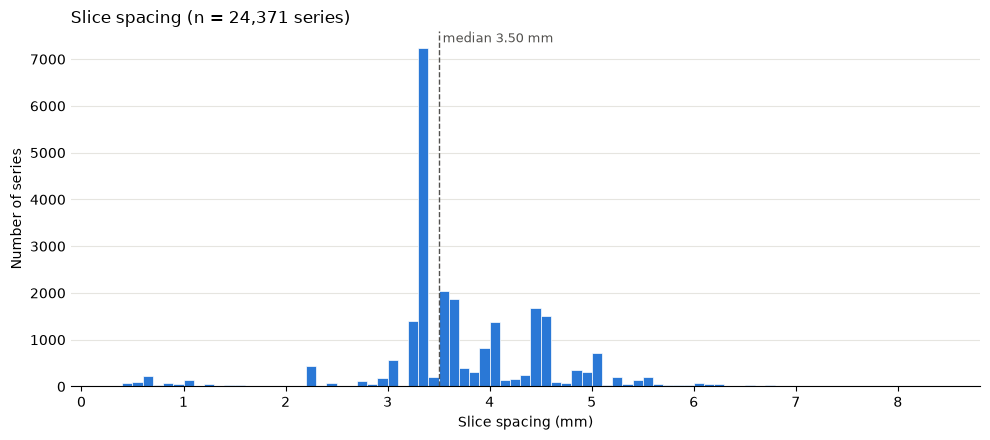

,count,mean,std,min,5%,50%,95%,max
Anatomical_Plane,,,,,,,,
Sagittal,9864.0,3.532,0.837,0.4,2.2,3.300,4.723,6.600
Coronal,8609.0,3.780,0.734,1.5,3.3,3.500,5.200,8.218
Axial,5898.0,3.828,1.184,0.6,0.6,3.665,5.500,8.328


In [3]:
# 2. Slice spacing (centre-to-centre distance of neighbouring slices)
histogram(geo["slice_spacing_mm"], bin_width=0.1, xlabel="Slice spacing (mm)", title="Slice spacing")
display(per_plane_summary("slice_spacing_mm"))


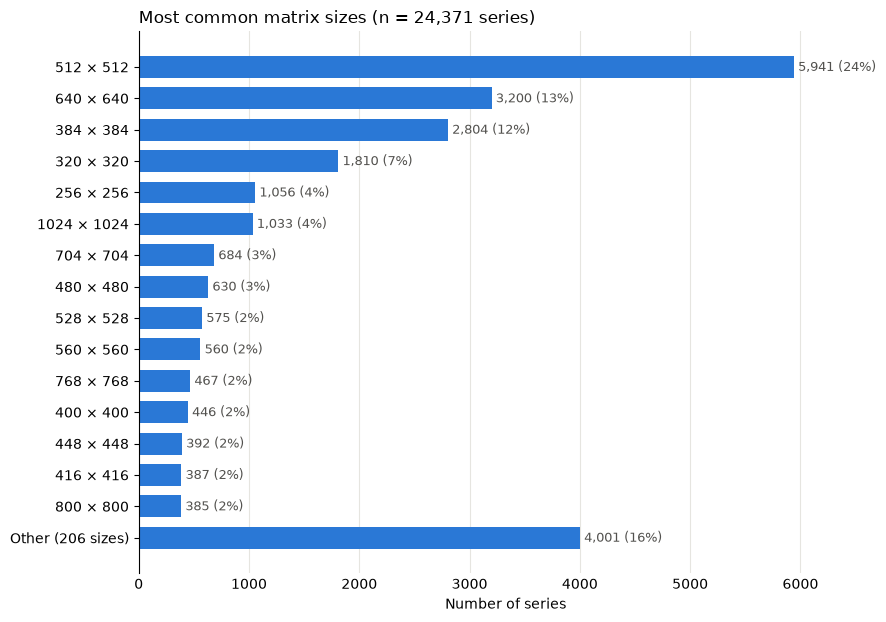

Square matrix: 92.7% of series


,min (rows),50% (rows),max (rows),min (cols),50% (cols),max (cols)
Anatomical_Plane,,,,,,
Sagittal,192.0,512.0,1200.0,192.0,512.0,1444.0
Coronal,192.0,512.0,1024.0,192.0,512.0,1072.0
Axial,160.0,512.0,1280.0,160.0,512.0,1280.0


In [4]:
# 3. Matrix size (rows × cols)
TOP_N = 15

matrix = geo["rows"].astype(int).astype(str) + " × " + geo["cols"].astype(int).astype(str)
matrix_counts = matrix.value_counts()
top = matrix_counts.head(TOP_N)
other = matrix_counts.iloc[TOP_N:]
if len(other):
    top = pd.concat([top, pd.Series({f"Other ({len(other)} sizes)": other.sum()})])

fig, ax = plt.subplots(figsize=(9, 0.32 * len(top) + 1.2))
bars = ax.barh(top.index[::-1], top.values[::-1], height=0.7, color=BAR_COLOR, zorder=2)
ax.bar_label(bars, labels=[f"{fmt_int(v)} ({v / len(matrix):.0%})" for v in top.values[::-1]],
             padding=3, fontsize=9, color=INK_MUTED)
ax.set_xlabel("Number of series")
ax.set_title(f"Most common matrix sizes (n = {fmt_int(len(matrix))} series)", loc="left", fontsize=12)
style_axes(ax, grid_axis="x")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

print(f"Square matrix: {(geo['rows'] == geo['cols']).mean():.1%} of series")
display(per_plane_summary("rows").join(per_plane_summary("cols"), lsuffix=" (rows)", rsuffix=" (cols)")
        [["min (rows)", "50% (rows)", "max (rows)", "min (cols)", "50% (cols)", "max (cols)"]])


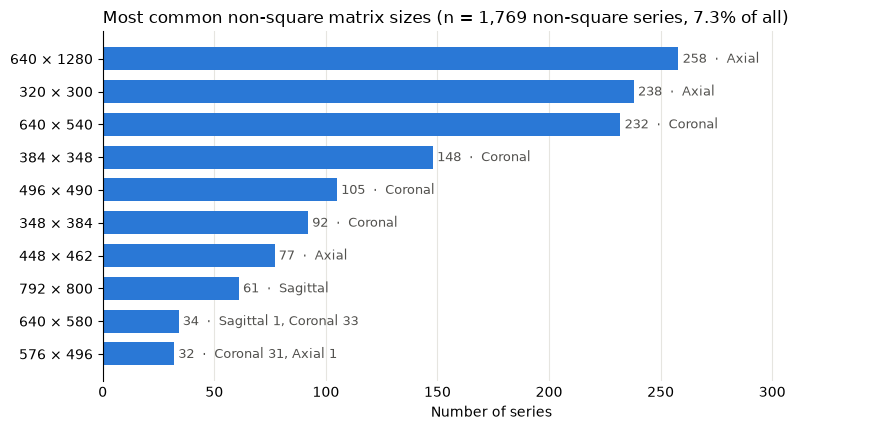

,n_series,n_studies,planes,median_spacing_mm,median_fov_mm
rows × cols,,,,,
640 × 1280,258,256,Axial,0.250,160 × 320
320 × 300,238,232,Axial,0.512,164 × 154
640 × 540,232,119,Coronal,0.250,160 × 135
384 × 348,148,144,Coronal,0.417,160 × 145
496 × 490,105,92,Coronal,0.321,159 × 157
348 × 384,92,90,Coronal,0.417,145 × 160
448 × 462,77,74,Axial,0.357,160 × 165
792 × 800,61,61,Sagittal,0.188,148 × 150
640 × 580,34,34,"Sagittal 1, Coronal 33",0.259,166 × 150


Example study / series for each size:
   640 × 1280  Axial     study 1.2.826.0.1.3680043.8.498.10243300429607935614655219482457289307  series 1.2.826.0.1.3680043.8.498.11813424485012618176922849479597231956
    320 × 300  Axial     study 1.2.826.0.1.3680043.8.498.10322724865012212544754724404226583315  series 1.2.826.0.1.3680043.8.498.41731945035369097344055161439283312539
    640 × 540  Coronal   study 1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585  series 1.2.826.0.1.3680043.8.498.87374594163896635184044513927478147680
    384 × 348  Coronal   study 1.2.826.0.1.3680043.8.498.10322724865012212544754724404226583315  series 1.2.826.0.1.3680043.8.498.93774185135543270972565445822183490170
    496 × 490  Coronal   study 1.2.826.0.1.3680043.8.498.10026410865298348818136520318965356394  series 1.2.826.0.1.3680043.8.498.36920113116383282710943538994927981876
    348 × 384  Coronal   study 1.2.826.0.1.3680043.8.498.10387227472110643414333498953513810066  series 1.2.826.0.1.3

In [5]:
# 4. Most common non-square matrix sizes
TOP_N_NON_SQUARE = 10

non_square = geo[geo["rows"] != geo["cols"]].assign(matrix=matrix)
top_sizes = non_square["matrix"].value_counts().head(TOP_N_NON_SQUARE).index
top_non_square = non_square[non_square["matrix"].isin(top_sizes)]


def plane_note(planes):
    counts = planes.value_counts().reindex(PLANE_ORDER).dropna().astype(int)
    if len(counts) == 1:
        return counts.index[0]
    return ", ".join(f"{plane} {fmt_int(n)}" for plane, n in counts.items())


non_square_table = (
    top_non_square.groupby("matrix")
    .agg(n_series=("SeriesInstanceUID", "size"),
         n_studies=("StudyInstanceUID", "nunique"),
         planes=("Anatomical_Plane", plane_note),
         median_spacing_mm=("inplane_spacing_mm", "median"))
    .reindex(top_sizes)
)
rows_cols = non_square_table.index.str.split(" × ", expand=True).to_frame().astype(int).to_numpy()
non_square_table["median_fov_mm"] = [
    f"{r * s:.0f} × {c * s:.0f}" for (r, c), s in zip(rows_cols, non_square_table["median_spacing_mm"])
]
non_square_table["median_spacing_mm"] = non_square_table["median_spacing_mm"].round(3)
non_square_table.index.name = "rows × cols"

fig, ax = plt.subplots(figsize=(9, 0.32 * len(non_square_table) + 1.2))
bars = ax.barh(non_square_table.index[::-1], non_square_table["n_series"][::-1], height=0.7, color=BAR_COLOR, zorder=2)
ax.bar_label(bars, labels=[f"{fmt_int(n)}  ·  {planes}"
                           for n, planes in zip(non_square_table["n_series"][::-1], non_square_table["planes"][::-1])],
             padding=3, fontsize=9, color=INK_MUTED)
ax.set_xlabel("Number of series")
ax.set_title(f"Most common non-square matrix sizes (n = {fmt_int(len(non_square))} non-square series, "
             f"{len(non_square) / len(geo):.1%} of all)", loc="left", fontsize=12)
style_axes(ax, grid_axis="x")
ax.margins(x=0.35)
plt.tight_layout()
plt.show()

display(non_square_table)

print("Example study / series for each size:")
examples = top_non_square.sort_values(["StudyInstanceUID", "SeriesInstanceUID"]).drop_duplicates("matrix").set_index("matrix")
for size in top_sizes:
    ex = examples.loc[size]
    print(f"  {size:>11}  {ex['Anatomical_Plane']:<8}  study {ex['StudyInstanceUID']}  series {ex['SeriesInstanceUID']}")